In [18]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_groq import ChatGroq
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import os

load_dotenv()

True

In [19]:
llm = ChatGroq(model='llama-3.1-8b-instant', api_key=os.getenv("GROQ_API_KEY"))

In [20]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [21]:
def chat_model(state: ChatState) -> ChatState:
    messages = state['messages']
    response = llm.invoke(messages)

    return {'messages': [response]}


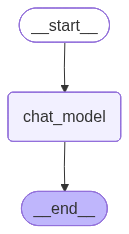

In [22]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node('chat_model', chat_model)

graph.add_edge(START, 'chat_model')
graph.add_edge('chat_model', END)

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [ ]:
thread_id = '1'
while True:
    user_input = input("You: ")
    if user_input.lower() in ['exit', 'quit', 'bye']:
        print("Exiting the chat. Goodbye!")
        break
    
    config = {'configurable': {'thread_id': thread_id}}
    response = workflow.invoke(
        {
            "messages": [
                HumanMessage(content=user_input)
            ]
        },
        config=config
    )
    print(f"You: {user_input}")
    print(f"Assistant: {response['messages'][-1].content}\n")

You: hello
Assistant: Hello. How can I help you today?

You: my name is priyashu
Assistant: Nice to meet you, Priyashu. Is there something I can help you with or would you like to chat?

You: what's my name
Assistant: Your name is Priyashu.

You: add 10 and 13
Assistant: 10 + 13 = 23

You: ow multiply the result with 2
Assistant: First, we have the result: 23

 Multiplying it by 2: 
23 * 2 = 46

Exiting the chat. Goodbye!
